# Baseline 2
*EDITED VERSION FOR LAB2*

Domain heuristic baseline + optional stretch metrics/model (see Section 4)

## Setup

In [31]:
# ── Reproducibility Header ────────────────────────────────────────────
# Every notebook in IIT414W starts here. Do not skip this block.

import sys, random
import numpy as np
import warnings

RANDOM_SEED = 414  # Course constant. Do not change.
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
warnings.filterwarnings('ignore', category=FutureWarning)

# Environment check
print(f'Python  : {sys.version.split()[0]}')
print(f'NumPy   : {np.__version__}')
print(f'Seed    : {RANDOM_SEED}')

# ── Dependency Guard ───────────────────────────────────────────────
# Ensures all required packages are installed in the active kernel.
# Safe to re-run: pip will skip already-installed packages.

import importlib, subprocess, sys

_REQUIRED = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'sklearn': 'scikit-learn',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'fastf1': 'fastf1',
}

_missing = []
for _mod, _pip in _REQUIRED.items():
    try:
        importlib.import_module(_mod)
    except ModuleNotFoundError:
        _missing.append(_pip)

if _missing:
    print(f'Installing missing packages: {_missing}')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet'] + _missing)
    print('Done. Packages installed successfully.')
else:
    print('All required packages already installed ✓')

# ── Library Imports ───────────────────────────────────────────────
import os                        # Working directory checks
import subprocess                # Git command checks
import importlib                 # Runtime dependency checks
import numpy as np               # Numeric support
import pandas as pd              # Tables and diagnostics
import matplotlib.pyplot as plt  # Plotting
import seaborn as sns            # Statistical plotting
import fastf1                    # Formula 1 data access

print(f'fastf1  : {fastf1.__version__}')
print(f'pandas  : {pd.__version__}')

Python  : 3.12.3
NumPy   : 2.4.2
Seed    : 414
All required packages already installed ✓
fastf1  : 3.8.1
pandas  : 2.3.3


In [32]:
# Load and prepare 2022-2024 race-result data from FastF1/Ergast for EDA.
import fastf1
import pandas as pd
import os

# ── YOUR TURN ──────────────────────────────────────────────────────────────
# Task: Implement majority-class and domain heuristic baselines on YOUR data.
# 
# Step 1: Load your Lab 1 data (copy your data loading code here)

# Configure local cache so repeated API reads are fast and reproducible.
cache_path = os.path.abspath("fastf1_cache")
os.makedirs(cache_path, exist_ok=True)
fastf1.Cache.enable_cache(cache_path)

# Create Ergast interface and iterate all race weekends in each season.
erg = fastf1.ergast.Ergast()

years = [2020, 2021, 2022, 2023, 2024]
results_list = []

for year in years:
    schedule = fastf1.get_event_schedule(year)

    for _, event in schedule.iterrows():
        # Ignore testing sessions because they are not part of race prediction.
        if event['EventFormat'] == 'testing':
            continue

        rnd = int(event['RoundNumber'])

        try:
            res = erg.get_race_results(season=year, round=rnd)
            race = res.content[0]

            # Keep temporal/event metadata for later grouping and split logic.
            race['year'] = year
            race['round'] = rnd
            race['circuit'] = event['EventName']

            results_list.append(race)

        except Exception as e:
            print(f"Skipping {year} round {rnd}")

# Merge all race result frames into one modeling table.
df = pd.concat(results_list, ignore_index=True)

# Keep only columns used in this lab.
df = df[[
    'driverNumber',
    'givenName',
    'familyName',
    'constructorName',
    'grid',
    'position',
    'status',
    'points',
    'year',
    'round',
    'circuit'
]]

# Standardize column names for readability.
df.columns = [
    'DriverNumber',
    'FirstName',
    'LastName',
    'TeamName',
    'GridPosition',
    'Position',
    'Status',
    'Points',
    'Year',
    'Round',
    'Circuit'
]

# Build convenient identity and numeric fields.
df['FullName'] = df['FirstName'] + " " + df['LastName']
df['GridPosition'] = pd.to_numeric(df['GridPosition'], errors='coerce')
df['Position'] = pd.to_numeric(df['Position'], errors='coerce')

# Feature engineering for baseline and analysis.
df['Top10'] = ((df['Position'] <= 10) & (df['Position'] >0)).astype(int)
df['BaselinePred'] = (df['GridPosition'] <= 10).astype(int)
df['PositionsGained'] = df['GridPosition'] - df['Position']
df['DNF'] = ~df['Status'].str.contains("Finished", na=False)

# Historical reliability and constructor strength proxies.
driver_reliability = 1 - df.groupby('FullName')['DNF'].mean()
df['DriverReliability'] = df['FullName'].map(driver_reliability)
constructor_points = df.groupby('TeamName')['Points'].mean()
df['ConstructorStrength'] = df['TeamName'].map(constructor_points)

# Remove unusable rows for grid/finish-based analyses.
df = df.dropna(subset=['GridPosition','Position'])

print("Dataset shape:", df.shape)


Dataset shape: (2139, 18)


In [33]:
df_trunq = df[['Top10','DriverNumber','TeamName','GridPosition','Year','Circuit', 'Round']].copy()
df_trunq.head()

,Top10,DriverNumber,TeamName,GridPosition,Year,Circuit,Round
0,1,77,Mercedes,1,2020,Austrian Grand Prix,1
1,1,16,Ferrari,7,2020,Austrian Grand Prix,1
2,1,1,McLaren,3,2020,Austrian Grand Prix,1
3,1,44,Mercedes,5,2020,Austrian Grand Prix,1
4,1,55,McLaren,8,2020,Austrian Grand Prix,1


## 0. Majority Class

In [ ]:
from sklearn.dummy import DummyClassifier         # Majority-class baseline
from sklearn.metrics import accuracy_score, classification_report

#splitting by Year, choice was for recency. 2023 to train (its a past season). 2024 to evaluate (test)
df_train = df_trunq[df_trunq["Year"].isin([2020, 2021,2022])].copy()
df_val = df_trunq[df_trunq["Year"]==2023].copy()
df_test = df_trunq[df_trunq["Year"]==2024].copy()
print(f"Training shape: {df_train.shape}\nValidation shape: {df_val.shape}\nTesting shape: {df_test.shape}")

y_train = df_train["Top10"]
X_train = df_train.drop(["Top10",'Year'], axis=1)

y_val = df_val["Top10"] 
X_val = df_val.drop("Top10", axis=1)

y_test = df_test["Top10"] 
X_test = df_test.drop("Top10", axis=1)

# Step 3: Run DummyClassifier — record the accuracy/F1 for Section 2
clf_majority = DummyClassifier(strategy='most_frequent', random_state=RANDOM_SEED)
clf_majority.fit(X_train, y_train)
y_pred_majority = clf_majority.predict(X_val)

majority_class = clf_majority.classes_[np.argmax(clf_majority.class_prior_)]
majority_label = "Top-10" if majority_class == 1 else "Not Top-10"

print("=== Majority-Class Baseline ===")
print(f"What it predicts: always class {majority_class} ({majority_label})")
print(f"Class balance (train): {y_train.mean():.3f} Top-10 | {1 - y_train.mean():.3f} Not Top-10\n")

print(classification_report(
    y_val, y_pred_majority,
    target_names=['Not Top-10', 'Top-10'],
    zero_division=0,
))

Training shape: (1220, 7)
Validation shape: (440, 7)
Testing shape: (479, 7)
=== Majority-Class Baseline ===
What it predicts: always class 0 (Not Top-10)
Class balance (train): 0.500 Top-10 | 0.500 Not Top-10

              precision    recall  f1-score   support

  Not Top-10       0.50      1.00      0.67       220
      Top-10       0.00      0.00      0.00       220

    accuracy                           0.50       440
   macro avg       0.25      0.50      0.33       440
weighted avg       0.25      0.50      0.33       440



## 1. Heuristic Baseline

1 domain heuristic baseline (rule-based, no ML code)


Heuristic Baseline: "Ferrari always ends in the top 10"

For this, we will be using pre-race variables such as year (to avoid leackage), vehicle (or TeamName), course (circuit) and driver.

In [35]:
#using 2023 to use 2024 to validate
print("STARTING ANALISIS FOR YEAR SPLIT: Is it useful? What years to choose, do they have enough data?\n")
print("="*60)
print("What years are we working with?:",df_trunq['Year'].unique())  #2022, 2023, 2024
print("How many entries per year?\n",df_trunq["Year"].value_counts())
print("% split?\n",df_trunq["Year"].value_counts()/len(df_trunq))

print("\nThey seem equal in amounts, so we're using 2023 to train, and 2024 to test")
print("="*60)

STARTING ANALISIS FOR YEAR SPLIT: Is it useful? What years to choose, do they have enough data?

What years are we working with?: [2020 2021 2022 2023 2024]
How many entries per year?
 Year
2024    479
2022    440
2021    440
2023    440
2020    340
Name: count, dtype: int64
% split?
 Year
2024    0.223936
2022    0.205704
2021    0.205704
2023    0.205704
2020    0.158953
Name: count, dtype: float64

They seem equal in amounts, so we're using 2023 to train, and 2024 to test


In [36]:
# Step 4: Implement your domain heuristic — record the number for Section 3
df_trunq = df[['Top10',  'TeamName', 'GridPosition', 'Year', 'Circuit', 'Round']].copy()

# Domain heuristic: predict Top-10 if starting grid position is in the first 10 slots.
df_trunq['HeuristicPred'] = (df_trunq['GridPosition'] <= 10).astype(int)
#We replace string values into int with et_dummies() 
dummies = pd.get_dummies(df_trunq['Circuit'],dtype = int)   # Create dummies
df_trunq = pd.concat([df_trunq, dummies], axis=1).drop(['Circuit', 'Bahrain Grand Prix'], axis=1)  # Merge & drop
dummies = pd.get_dummies(df_trunq['TeamName'],dtype = int)   # Create dummies
df_trunq = pd.concat([df_trunq, dummies], axis=1).drop(['TeamName', 'Mercedes'], axis=1)  # Merge & dropdummies = pd.get_dummies(df_trunq['TeamName'],dtype = int)   # Create dummies


#df['Circuit'] = pd.to_numeric(df['Circuit'])
print("Dataset shape:", df_trunq.shape)

df_trunq.head()

#y_val = df_val["Top10"]
#y_pred_heuristic = df_val["HeuristicPred"]


Dataset shape: (2139, 50)


,Top10,GridPosition,Year,Round,HeuristicPred,70th Anniversary Grand Prix,Abu Dhabi Grand Prix,Australian Grand Prix,Austrian Grand Prix,Azerbaijan Grand Prix,...,Aston Martin,Ferrari,Haas F1 Team,McLaren,RB F1 Team,Racing Point,Red Bull,Renault,Sauber,Williams
0,1,1,2020,1,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,1,7,2020,1,1,0,0,0,1,0,...,0,1,0,0,0,0,0,0,0,0
2,1,3,2020,1,1,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
3,1,5,2020,1,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,1,8,2020,1,1,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0


In [37]:
#splitting by Year, choice was for recency. 2023 to train (its a past season). 2024 to evaluate (test)
df_train = df_trunq[df_trunq["Year"].isin([2020, 2021,2022])].copy()
df_val = df_trunq[df_trunq["Year"]==2023].copy()
df_test = df_trunq[df_trunq["Year"]==2024].copy()
print(f"Training shape: {df_train.shape}\nValidation shape: {df_val.shape}\nTesting shape: {df_test.shape}")

y_train = df_train["Top10"]
X_train = df_train.drop(["Top10",'Year'], axis=1)

y_val = df_val["Top10"] 
X_val = df_val.drop(["Top10",'Year'], axis=1)

y_test = df_test["Top10"] 
X_test = df_test.drop(["Top10",'Year'], axis=1)

Training shape: (1220, 50)
Validation shape: (440, 50)
Testing shape: (479, 50)


"Logistic Regression uses gradient based optimization which is sensitive to feature magnitudes, so scaling helps the model train correctly. The scaler is fit only on training data and then applied to test data to avoid data leakage."

From: https://www.geeksforgeeks.org/machine-learning/ml-logistic-regression-using-python/

In [38]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Creating a model

In [39]:
from sklearn.linear_model import LogisticRegression #Binary prediction with LogisticRegression
# Create and train a model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## 2. Accuracy tests
□ baseline.ipynb — Accuracy reported on validation set (not training set)


In [40]:
from sklearn.metrics import accuracy_score

#predict
y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")  # 0.69
print(f"Majority baseline: {y_test.mean():.2f}")          # 0.40
# → 29% above always-predicting-majority. 

Accuracy: 0.67
Majority baseline: 0.50


## 3. Reflection
□ baseline.ipynb — Reflection: "What could accuracy be hiding?"


Our obtained accuracy is above the Majority Baseline by 29 points, so its not completely useless. However, it's not as high as it could be, so perhaps we dropped useful features, or relied too much on the ones selected.

Perhaps its (almost) 70% comes from the fact that the set of features pre-race are not so consistent at predicting (a theory that would have to be tested in future labs or classes), or the use of just one year (instead of using both 2022 and 2023 to train), or the use of a model (better models for boolean predictions?)

## 4. Lower bound Statement
□ baseline.ipynb — Lower bound statement: "Lab 2 model must beat this"


For the next lab, our goal is to have an accuracy above 80% (ideally above 85%), but with the previously proposed theory, this may prove a challenge.

## 5. Leackage Check


Thanks to this table, we know the features that are safe, and those that risk leackage

| Column | Type | Cardinality | % Missing | Available Pre-Race? | Leakage Risk? | Notes |
|--------|------|-------------|-----------|---------------------|---------------|-------|
| `season` | int | 3 | 0% | ✅ Yes | No | Calendar feature |
| `round` | int | 24 | 0% | ✅ Yes | No | Calendar feature |
| `race_name` | str | ~24 | 0% | ✅ Yes | No | Categorical, could encode circuit traits |
| `circuit` | str | ~24 | 0% | ✅ Yes | No | Key grouping variable |
| `date` | str | ~69 | 0% | ✅ Yes | No | Temporal ordering |
| `driver` | str | ~28 | 0% | ✅ Yes | No | Driver identity — available from entry list |
| `driver_name` | str | ~28 | 0% | ✅ Yes | No | Display name |
| `constructor` | str | ~10 | 0% | ✅ Yes | No | Team identity |
| `grid` | int | 20+ | 0% | ✅ Yes (after qualifying) | No | **Strong feature** — known before race start |
| `position` | float | 20+ | ~5% | ❌ **No** — this is the outcome | ⚠️ **LEAKAGE** | This is typically what we want to **predict** |
| `points` | float | ~15 | 0% | ❌ **No** — awarded after race | ⚠️ **LEAKAGE** | Derived from `position` |
| `status` | str | 15+ | 0% | ❌ **No** — only known after race | ⚠️ **LEAKAGE** | Finished, DNF, crash, etc. |
| `laps` | int | ~60 | 0% | ❌ **No** — only known after race | ⚠️ **LEAKAGE** | DNF drivers complete fewer laps |

**Key takeaway:** Only `season`, `round`, `circuit`, `date`, `driver`, `constructor`, and `grid` are safe to use as features for predicting race outcome. Everything else either *is* the outcome or is derived from it.

In [41]:
print(list(df.columns))

['DriverNumber', 'FirstName', 'LastName', 'TeamName', 'GridPosition', 'Position', 'Status', 'Points', 'Year', 'Round', 'Circuit', 'FullName', 'Top10', 'BaselinePred', 'PositionsGained', 'DNF', 'DriverReliability', 'ConstructorStrength']


We used status as the predictor and NOT as features for predicting, so the usage of these columns is leackage safe (dont forget Constructor and CIrcuit were transformed with "get_dummies()" for use within our model)

# OPTIONAL Stretch
STRETCH — optional, rewarded if present:

### Additional metrics (Precision, Recall, F1, ROC-AUC)

From: https://www.geeksforgeeks.org/machine-learning/difference-between-score-and-accuracy_score-methods-in-scikit-learn/ and https://www.geeksforgeeks.org/machine-learning/ml-logistic-regression-using-python/

ADDITIONAL METRICS
Precision: 0.62
Recall: 0.89
f1 score: 0.73
ROC AUC: 0.8088737796373779

SOME EXTRA
Confussion Matrix:
 [[107 132]
 [ 27 213]]


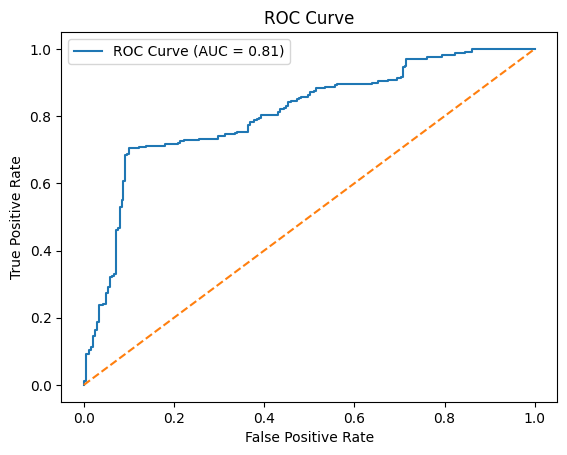

In [42]:
from sklearn.metrics import  confusion_matrix, precision_score, recall_score,f1_score,roc_curve, roc_auc_score
print("ADDITIONAL METRICS")
print("="*60)
precision = precision_score(y_test, y_pred)
print(f"Precision: {round(precision,2)}")
recall = recall_score(y_test, y_pred)
print(f"Recall: {round(recall,2)}")
f1 = f1_score(y_test, y_pred)
print(f"f1 score: {round(f1,2)}")

y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC AUC:", roc_auc)

print("\nSOME EXTRA")
cm = confusion_matrix(y_test, y_pred)
print("Confussion Matrix:\n",cm)
print("="*60)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--") 
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Second baseline (sklearn model or second heuristic)

From: https://www.geeksforgeeks.org/machine-learning/comprehensive-guide-to-classification-models-in-scikit-learn/#1-logistic-regression

From here, we choose a KNN model, for the purpose of the classification parameters used in the dataset (Circuit, Constructor)

"KNN is a simple, instance-based learning algorithm. It classifies a data point based on the majority class among its k-nearest neighbors." - GeeksforGeeks

In [43]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

Accuracy: 0.6409185803757829
              precision    recall  f1-score   support

           0       0.71      0.48      0.57       239
           1       0.61      0.80      0.69       240

    accuracy                           0.64       479
   macro avg       0.66      0.64      0.63       479
weighted avg       0.66      0.64      0.63       479



### Metric choice justification

Using a Confussion Matrix is an easy way to visualize how good our model's predictions fare against the actual data. In this case:
>True when they DNF.

>False when they dont.

[ TP , FN ]

[ FN , TN ]

In [44]:
print("Confussion Matrix:\n",cm*100/len(df_test))

Confussion Matrix:
 [[22.33820459 27.55741127]
 [ 5.63674322 44.46764092]]


As we can see, our current model has a high amount of False Negatives (25%~). This is something to look out for and investigate within the parameters used. Thanks to the CM, this fact becomes very clear to us.